In [2]:
!pip3 install pandas
import pandas as pd
import numpy as np

df = pd.read_csv("/workspaces/ml-assessment-swethapriya/data/q2_customers.csv")
print(df)

     age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0     30         43075                 9         2080                     45   
1     19         14496                11          454                      8   
2     43         57632                 6         2144                     16   
3     30         15629                10          801                      0   
4     19         14901                16          396                     17   
..   ...           ...               ...          ...                    ...   
495   20         22094                13          729                      3   
496   53         63845                 1         7371                     30   
497   44         53558                 9          906                     10   
498   36         41202                 9         2046                     47   
499   20          8118                15          865                     16   

     num_categories_purchased  
0      

In [3]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# droping any non-numberic columns
df_numeric = df.select_dtypes(include = 'number')

#Scaling the feature using standard scaler
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df_numeric)

print(df_numeric.describe().round(2))
print(scaled_df.shape)
#print(scaled_df.round(2))

          age  annual_spend  visits_per_month  basket_size  \
count  500.00        500.00            500.00       500.00   
mean    40.45      48856.95              8.41      2682.29   
std     14.43      32856.80              5.32      2274.96   
min     18.00       5038.00              1.00       212.00   
25%     28.00      19213.25              4.00       727.75   
50%     41.00      44257.00              8.00      2051.50   
75%     50.00      75373.00             12.00      4223.75   
max     69.00     119757.00             19.00      7981.00   

       days_since_last_visit  num_categories_purchased  
count                 500.00                    500.00  
mean                   49.47                      4.66  
std                    49.70                      2.44  
min                     0.00                      1.00  
25%                    12.00                      3.00  
50%                    33.00                      4.00  
75%                    61.25              

Standard scaler fixes the data by transforming every feature to have a mean of  0 and Standard deviation of 1, so that feature contributes equally when K-means measures distances. without scaling the results will be misleading and will be biased to high ranked(marked) features.

For example: if we consider age between 18-70 and annual income between 20k-200K, income will dominate just because numbers are high which clearly shows biased data.



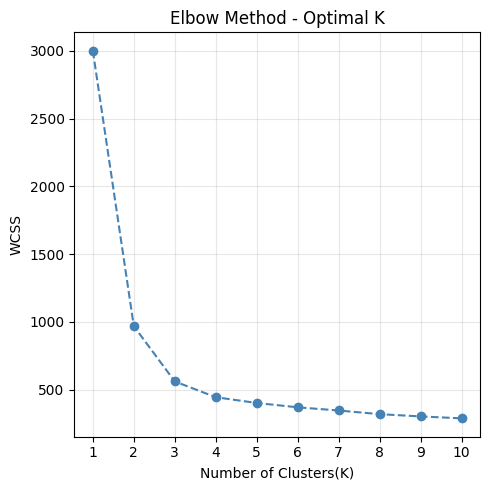

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(5,5))
plt.plot(range(1,11), wcss, marker = 'o', linestyle='--', color = 'steelblue')
plt.title('Elbow Method - Optimal K')
plt.xlabel('Number of Clusters(K)')
plt.ylabel('WCSS')
plt.xticks(range(1,11))
plt.grid(True, alpha= 0.3)
plt.tight_layout()
plt.show()

The elbow plot shows WCSS dropping steeply from k=1 to k=3,  after which the rate of decrease slows down significantly and the curve begins to flatten. This elbow point at k = 3 suggests that adding more clustures beyond 3 gives very little improvement. 
So, k = 3 is selected as optimal number of clustures.It captures the main natural groupings in the data without overfitting by creating many small fragmented clustures.


In [5]:
from sklearn.cluster import KMeans

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10 )
kmeans.fit(scaled_df)

# Adding clusture column
df['cluster'] = kmeans.labels_

#printing cluster
centers_df = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns= df_numeric.columns
)

centers_df.index.name = 'Cluster'
centers_df.index = centers_df.index + 1

print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())

print("\nCluster Centroids:")
print(centers_df.round(2))

Cluster sizes:
cluster
0    170
1    165
2    165
Name: count, dtype: int64

Cluster Centroids:
           age  annual_spend  visits_per_month  basket_size  \
Cluster                                                       
1        24.68      14847.37             14.34       558.97   
2        56.77      89413.33              2.53      5530.55   
3        40.39      43340.73              8.19      2021.68   

         days_since_last_visit  num_categories_purchased  
Cluster                                                   
1                         9.08                      2.11  
2                       105.36                      7.52  
3                        35.19                      4.42  


In [6]:
from sklearn.cluster import KMeans


#K-menas with optimal K=3
kmeans = KMeans(n_clusters=3, init='k-means++',n_init=10, random_state =42)
kmeans.fit(scaled_df)

df['Cluster'] = kmeans.labels_

print("Cluster centers(Scaled): ",kmeans.cluster_centers_)
print("\n Cluster Distribution:")
print(df['Cluster'].value_counts().sort_index())



Cluster centers(Scaled):  [[-1.09459502 -1.03612168  1.11428439 -0.9342777  -0.8134945  -1.04534595]
 [ 1.13221365  1.23557402 -1.10668011  1.25325954  1.12572466  1.17299127]
 [-0.00444909 -0.16805471 -0.04137047 -0.29067039 -0.28757882 -0.09596817]]

 Cluster Distribution:
Cluster
0    170
1    165
2    165
Name: count, dtype: int64


In [7]:
df['Cluster'] = kmeans.labels_
print(df['Cluster'].value_counts())
print(df.head())

Cluster
0    170
2    165
1    165
Name: count, dtype: int64
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  cluster  Cluster  
0                         6        2        2  
1                         3        0        0  
2                         4        2        2  
3                         2        0        0  
4                         1        0        0  


In [8]:
print(df.columns.tolist())
print(df.shape)
print(kmeans.cluster_centers_.shape)

['age', 'annual_spend', 'visits_per_month', 'basket_size', 'days_since_last_visit', 'num_categories_purchased', 'cluster', 'Cluster']
(500, 8)
(3, 6)


In [9]:
feature_cols = df.columns.drop(['Cluster', 'cluster'])

centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=feature_cols
)
centroids.index.name = 'Cluster'
print(centroids.round(2))

           age  annual_spend  visits_per_month  basket_size  \
Cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        56.77      89413.33              2.53      5530.55   
2        40.39      43340.73              8.19      2021.68   

         days_since_last_visit  num_categories_purchased  
Cluster                                                   
0                         9.08                      2.11  
1                       105.36                      7.52  
2                        35.19                      4.42  


In [10]:
pd.set_option('display.max_columns', None)
print(centroids.round(2))

           age  annual_spend  visits_per_month  basket_size  \
Cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        56.77      89413.33              2.53      5530.55   
2        40.39      43340.73              8.19      2021.68   

         days_since_last_visit  num_categories_purchased  
Cluster                                                   
0                         9.08                      2.11  
1                       105.36                      7.52  
2                        35.19                      4.42  


In [11]:
display(centroids.round(2)) 

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster,,,,,,
0,24.68,14847.37,14.34,558.97,9.08,2.11
1,56.77,89413.33,2.53,5530.55,105.36,7.52
2,40.39,43340.73,8.19,2021.68,35.19,4.42



Cluster '0' : Young Occasional customers.They often browse but rarely buy.  Age (age around 25), very low annual spend ($14,847), high visit frequency (14/month) but tiny basket size ($559).  .

Cluster 1: Rare visitors. These are VIPs who are worth re-engaging. Loyalists, Middle-aged (57), highest spenders ($89,413/year), large baskets ($5,530), widest category spread (7.5). However, they haven't visited recently (105 days). . 

Cluster 2: These are reliable Mid-Tier Customers. Average age (40), moderate spend ($43,340), healthy visit frequency (8/month), decent basket size ($2,021) and category breadth (4.4).

# Business Takeaways

Cluster 0 — Convert browsers to buyers; targeted promotions or loyalty incentives can improve basket size
Cluster 1  — Stable customers. Provide loyalty cash back offers to retain them. These are the important customers.
Cluster 2 — The stable lot; focus on upselling and increasing category exploration. 



In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(pca_coords, columns = ['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster'].values

print(pca_df.head())
print(f"\nVariance Ratio Explained : {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {pca.explained_variance_ratio_.sum():.2%}")

        PC1       PC2  Cluster
0 -0.333082  0.109379        2
1 -2.255362  0.048458        0
2 -0.092905 -0.679257        2
3 -2.017598 -0.308845        0
4 -2.917762  0.529368        0

Variance Ratio Explained : [0.83560354 0.05568764]
Total Variance Explained: 89.13%


In [13]:
loadings = pd.DataFrame(
    pca.components_,
    columns=feature_cols,
    index = ['PC1', 'PC2']  
)

print(loadings.round(4))



        age  annual_spend  visits_per_month  basket_size  \
PC1  0.4116        0.4215           -0.4104       0.4120   
PC2 -0.2594       -0.0333            0.2083      -0.1954   

     days_since_last_visit  num_categories_purchased  
PC1                 0.3786                    0.4140  
PC2                 0.9112                   -0.1405  


PC1: This component separates high-spending, older, broad-category shoppers who visit less frequently from low-spending, younger customers who visit often but buy little.
A higher PC1 score = higher value customer.
PC1:  Spend, basket, age vs. visit frequency

PC2: PC2 is almost entirely dominated by days_since_last_visit** (0.9112), with all other loadings close to zero. This component isolates how recently a customer last visited, independent of their spending behaviour. A higher PC2 score = more lapsed/inactive customer.
PC2:  Days since last visit, Recency




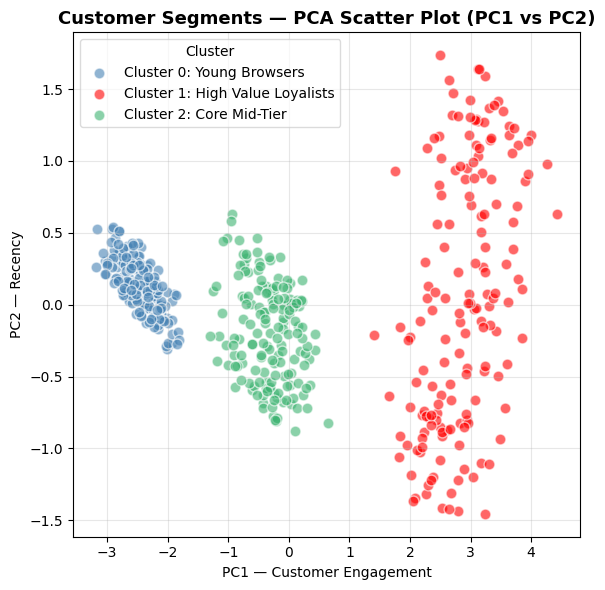

In [16]:
import matplotlib.pyplot as plt

colors = ['steelblue', 'red', 'mediumseagreen']
labels = ['Cluster 0: Young Browsers', 'Cluster 1: High Value Loyalists', 'Cluster 2: Core Mid-Tier']

plt.figure(figsize=(6,6))
for cluster in sorted(pca_df['Cluster'].unique()):
    mask = pca_df['Cluster'] == cluster
    plt.scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        label=labels[cluster],
        color= colors[cluster],
        alpha = 0.6,
        edgecolors ='white',
        s=60
    )


plt.title('Customer Segments — PCA Scatter Plot (PC1 vs PC2)', fontsize=13, fontweight='bold')
plt.xlabel('PC1 — Customer Engagement')
plt.ylabel('PC2 — Recency')
plt.legend(title='Cluster', framealpha=0.7)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
